Detected Encoding: {'encoding': 'Windows-1252', 'confidence': 0.7272080023536335, 'language': ''}
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 

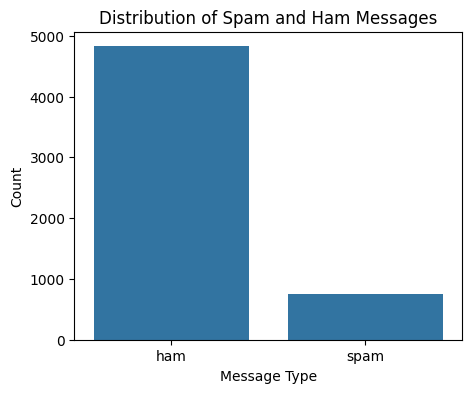

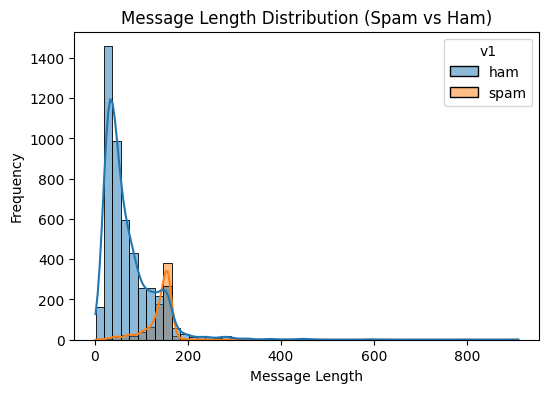

Accuracy: 0.9811659192825112

Classification Report:
               precision    recall  f1-score   support

         ham       0.98      1.00      0.99       949
        spam       0.98      0.89      0.93       166

    accuracy                           0.98      1115
   macro avg       0.98      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



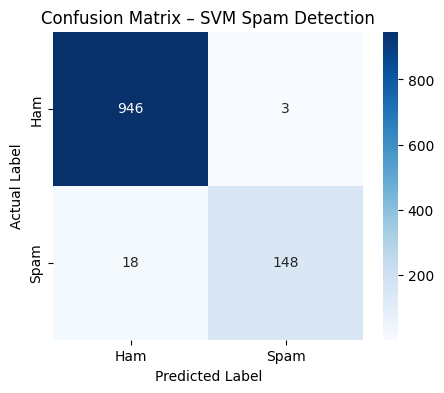

In [2]:
# Exp 11 – SVM for Spam Mail Detection with Visualization

# 1. Import Required Libraries
import chardet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2. Detect File Encoding
file_path = "spam.csv"   # use "/content/spam.csv" for Colab

with open(file_path, 'rb') as rawdata:
    result = chardet.detect(rawdata.read(100000))

print("Detected Encoding:", result)

# 3. Load Dataset
data = pd.read_csv(file_path, encoding=result['encoding'])

# 4. Basic Data Exploration
print(data.head())
print(data.info())
print(data.isnull().sum())

# 5. Visualization: Spam vs Ham Distribution
plt.figure(figsize=(5,4))
sns.countplot(x=data['v1'])
plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.show()

# 6. Message Length Visualization
data['msg_length'] = data['v2'].apply(len)

plt.figure(figsize=(6,4))
sns.histplot(data=data, x='msg_length', hue='v1', bins=50, kde=True)
plt.title("Message Length Distribution (Spam vs Ham)")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.show()

# 7. Feature and Target Selection
x = data['v2'].values     # messages
y = data['v1'].values     # labels

# 8. Train-Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

# 9. Text Vectorization (Bag of Words)
cv = CountVectorizer()
x_train_vec = cv.fit_transform(x_train)
x_test_vec = cv.transform(x_test)

# 10. Initialize and Train SVM
svc = SVC(kernel='linear')
svc.fit(x_train_vec, y_train)

# 11. Prediction
y_pred = svc.predict(x_test_vec)

# 12. Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 13. Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title("Confusion Matrix – SVM Spam Detection")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()


In [1]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv
